In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install gensim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<h2>1. Data Loading </h2>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Colab_Objects/data/unisa_undergrad_qualif_2024_12_03_08_21_32.csv'
df = pd.read_csv(file_path)
df.head()

,name,code,saqa_id,dep,aps,faculty,nqf,credits,desc,comments,school,url
0,Higher Certificate in Banking (98225),98225,84286,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The primary purpose of the q...,\nRules:\nStudents who have already passed BAN...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
1,Higher Certificate in Economic and Management ...,98237,90677,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The purpose of this qualific...,\nRules:Students should note that during the c...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
2,Higher Certificate in Marketing (98229),98229,84766,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The primary purpose of this ...,\nRules:\nThe College has replaced EUP1501 wit...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
3,Higher Certificate in Retailing (90014),90014,94791,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The purpose of the qualifica...,\nRules:\nStudents who have already passed MNM...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
4,Higher Certificate in Supervisory Management (...,90015,94630,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The purpose of this qualific...,\nRules:\nStudents should note that during the...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...


<h2>2. Raw Feature Matrix Collection </h2>

In [ ]:
features_df = df.loc[:,['desc','comments','code','name','faculty']]
features_df['raw_features'] = features_df['desc']+' '+features_df['comments']+' '+features_df['name']
features_df.head()

,desc,comments,code,name,faculty,raw_features
0,Purpose statement:The primary purpose of the q...,\nRules:\nStudents who have already passed BAN...,98225,Higher Certificate in Banking (98225),Economic and Management Sciences,Purpose statement:The primary purpose of the q...
1,Purpose statement:The purpose of this qualific...,\nRules:Students should note that during the c...,98237,Higher Certificate in Economic and Management ...,Economic and Management Sciences,Purpose statement:The purpose of this qualific...
2,Purpose statement:The primary purpose of this ...,\nRules:\nThe College has replaced EUP1501 wit...,98229,Higher Certificate in Marketing (98229),Economic and Management Sciences,Purpose statement:The primary purpose of this ...
3,Purpose statement:The purpose of the qualifica...,\nRules:\nStudents who have already passed MNM...,90014,Higher Certificate in Retailing (90014),Economic and Management Sciences,Purpose statement:The purpose of the qualifica...
4,Purpose statement:The purpose of this qualific...,\nRules:\nStudents should note that during the...,90015,Higher Certificate in Supervisory Management (...,Economic and Management Sciences,Purpose statement:The purpose of this qualific...


<h2>3. Preprocessing </h2>

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    # Tokenize the text
    words = word_tokenize(text)
    # Get the list of English stopwords
    stop_words = set(stopwords.words('english'))
    # Remove stopwords
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # Join the filtered words back into a string
    text = ' '.join(filtered_words)
    comments_words = ['purpose','may','required','skills','students','level','subject','internet','statement','rules','qualification']
    for word in comments_words:
        text = text.replace(word,'')
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()
    clean_text = text
    return clean_text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
features_df['features'] = features_df['raw_features'].apply(preprocess)
features_df[['features','raw_features','faculty','code']].head()

,features,raw_features,faculty,code
0,primary closely tied rationale introduce learn...,Purpose statement:The primary purpose of the q...,Economic and Management Sciences,98225
1,prepare learners comply minimum statutory inst...,Purpose statement:The purpose of this qualific...,Economic and Management Sciences,98237
2,primary closely tied rationale serves provide ...,Purpose statement:The primary purpose of this ...,Economic and Management Sciences,98229
3,equip learners knowledge enter retailing envir...,Purpose statement:The purpose of the qualifica...,Economic and Management Sciences,90014
4,prepare learners operate perform operational o...,Purpose statement:The purpose of this qualific...,Economic and Management Sciences,90015


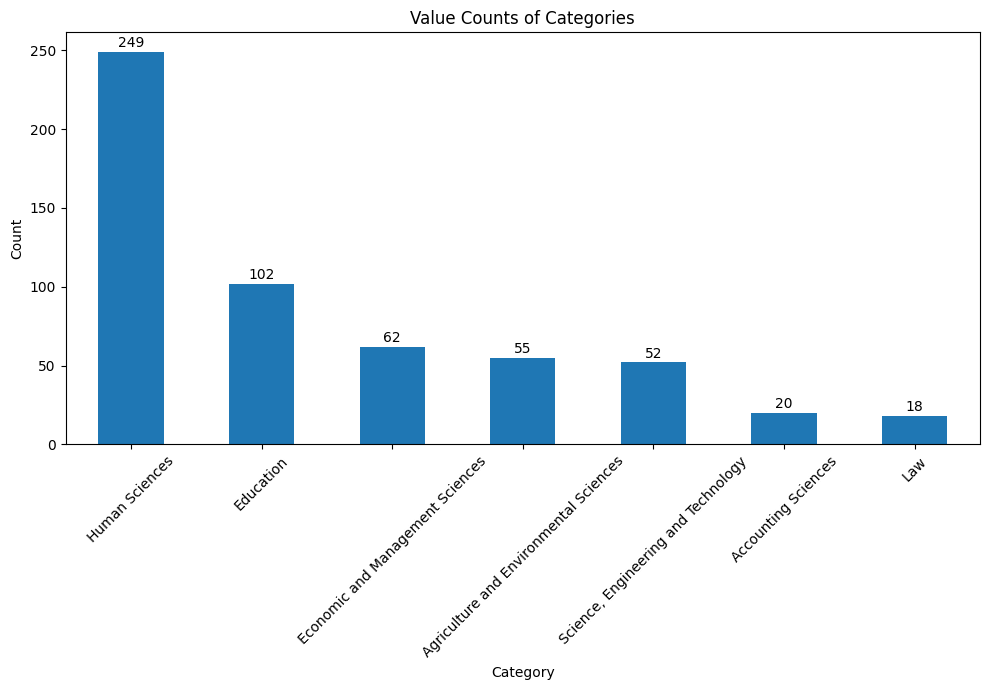

In [ ]:
import matplotlib.pyplot as plt

value_counts = features_df['faculty'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
bars = value_counts.plot(kind='bar', ax=ax, rot=45)

for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height-6),
                xytext=(0, 8),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_title('Value Counts of Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


<h2>3. Feature - Target Split</h2>

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Fit Label encoder and return encoded labels
#y = y_balanced #features_df['faculty']
#X = X_balanced #features_df['features']
y = features_df['faculty']
X = features_df['features']
#type_labels = list(le.classes_)

<h2>4. SBERT Implementation</h2>

In [ ]:
from sentence_transformers import SentenceTransformer, util
# Load a pre-trained SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")  # Optimized for sentence similarity

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
paragraph1 = "a man and a woman. I love dogs"
paragraph2 = "a male and a female. I love pets"
# Generate embeddings
embedding1 = model.encode(paragraph1, convert_to_tensor=True)
embedding2 = model.encode(paragraph2, convert_to_tensor=True)
# Compute Cosine Similarity
similarity_score = util.pytorch_cos_sim(embedding1, embedding2).item()
print(f"Similarity Score: {similarity_score:.4f}")  # Output: 0.85 (Higher means more similar)

Similarity Score: 0.8218


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.base import BaseEstimator, TransformerMixin

class BaseBERTVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def transform(self, raw_documents):
        # SBERT handles all preprocessing internally
        embeddings = self.model.encode(raw_documents, convert_to_numpy=True, show_progress_bar=False)
        return embeddings

    def fit(self, X, y=None):
        return self

In [ ]:
documents = [
    "This is a good course for students.",
    "It requires a strong internet connection and programming skills."
]

vectorizer = BaseBERTVectorizer()
X_ = vectorizer.fit_transform(documents)
print(X_.shape)  # (2, 384) if using 'all-MiniLM-L6-v2'


(2, 384)


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import nltk
import re

nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

class BERTVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name="all-MiniLM-L6-v2", max_chunk_chars=300):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)
        self.max_chunk_chars = max_chunk_chars  # Roughly ~100–150 words

    def split_into_chunks(self, text):
        # Split into sentences
        sentences = sent_tokenize(text)
        chunks = []
        current_chunk = ""

        for sentence in sentences:
            if len(current_chunk) + len(sentence) < self.max_chunk_chars:
                current_chunk += " " + sentence
            else:
                chunks.append(current_chunk.strip())
                current_chunk = sentence

        if current_chunk:
            chunks.append(current_chunk.strip())
        return chunks

    def transform(self, raw_documents):
        final_embeddings = []

        for doc in raw_documents:
            chunks = self.split_into_chunks(doc)
            chunk_embeddings = self.model.encode(chunks, convert_to_numpy=True, show_progress_bar=False)

            # Average embeddings across all chunks
            doc_embedding = np.mean(chunk_embeddings, axis=0)
            final_embeddings.append(doc_embedding)

        return np.array(final_embeddings)

    def fit(self, X, y=None):
        return self


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
docs = [
    "This is a short document.",
    "This is a very long document. " * 100  # Simulate a long document
]
vec = BERTVectorizer()
embeddings = vec.transform(docs)
print(embeddings.shape)  # (2, 384) for MiniLM


(2, 384)


In [ ]:
X.shape

(558,)

<h2>3. Crossvalidation </h2>

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define scoring metrics
# Updated scorers with zero_division=0
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

In [ ]:
"""
"XGBoost": grid_search_wrapper(
        XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        param_grid={
            'max_depth': [8,12,None]
        }
    )
"""

'\n"XGBoost": grid_search_wrapper(\n        XGBClassifier(use_label_encoder=False, eval_metric=\'mlogloss\', random_state=42),\n        param_grid={\n            \'max_depth\': [8,12,None]\n        }\n    )\n'

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
#from xgboost import XGBClassifier

def grid_search_wrapper(model, param_grid, scoring='f1_macro', cv=3):
    return GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

# List of classifiers to compare
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": grid_search_wrapper(
        DecisionTreeClassifier(random_state=42),
        param_grid={
            'max_depth': [8,12, None],
            'min_samples_leaf':[1,2,3]
        }
    )
    ,
    "MLP Classifier": grid_search_wrapper(
        MLPClassifier(max_iter=500, random_state=42,activation='relu'),
        param_grid={
            'hidden_layer_sizes': [(100,80), (120,100,80,50), (100,80,50,30)],
            'solver': ['adam']
        }
    )
}

In [ ]:
from sklearn.model_selection import StratifiedKFold
from collections import defaultdict
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.base import clone

# Optional: Enable or disable upsampling
apply_upsampling = False  # Set to False to disable

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Collect final results
final_results = []

# Store best instance (vectoriser + model) for each classifier
best_per_model = {}

# Iterate over classifiers
for model_name, clf in classifiers.items():
    print(f"\n====== {model_name} ======")

    metrics = defaultdict(list)
    all_conf_matrices = []

    best_f1 = -1
    best_model_instance = None
    best_vectoriser_instance = None

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        print(f"\n--- Fold {fold_idx} ---")
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Optional upsampling
        if apply_upsampling:
            df_train = pd.DataFrame({'text': X_train_raw, 'label': y_train})
            max_class_size = df_train['label'].value_counts().max()
            df_upsampled = pd.concat([
                resample(
                    df_train[df_train['label'] == label],
                    replace=True,
                    n_samples=max_class_size,
                    random_state=42
                )
                for label in df_train['label'].unique()
            ])
            df_upsampled = df_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)
            X_train_raw = df_upsampled['text']
            y_train = df_upsampled['label']
            print(f"Applied upsampling: New training distribution:\n{y_train.value_counts()}")

        # BERT Vectorisation
        BERT_vectorizer = BERTVectorizer()
        X_train = BERT_vectorizer.fit_transform(X_train_raw)
        X_test = BERT_vectorizer.transform(X_test_raw)
        print("train",X_train.shape)
        print("test",X_test.shape)
        #print("Word2Vec Vocabulary size:", len(w2v_vectorizer.vocabulary_))

        #clf_instance = clf.__class__(**clf.get_params())
        clf_instance = clone(clf)
        clf_instance.fit(X_train, y_train)

        y_pred = clf_instance.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

        metrics['Accuracy'].append(acc)
        metrics['Precision'].append(prec)
        metrics['Recall'].append(rec)
        metrics['F1-Score'].append(f1)
        all_conf_matrices.append(cm)

        if f1 > best_f1:
            best_f1 = f1
            best_model_instance = clf_instance
            best_vectoriser_instance = BERT_vectorizer

    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}
    avg_metrics['Model'] = model_name
    final_results.append(avg_metrics)

    best_per_model[model_name] = {
        'f1': best_f1,
        'model': best_model_instance,
        'vectoriser': best_vectoriser_instance
    }

df_results = pd.DataFrame(final_results)
print("\n======= Final Averaged Results Across All Folds =======")
print(df_results)

print("\nBest fold per classifier (F1-score):")
for name, entry in best_per_model.items():
    print(f"{name}: F1 = {entry['f1']:.4f}")


====== Logistic Regression ======

--- Fold 1 ---
train (446, 384)
test (112, 384)
Confusion Matrix:
 [[ 0  0  3  0  1  0  0]
 [ 0  6  1  1  3  0  0]
 [ 0  0 10  0  3  0  0]
 [ 0  0  0 20  0  0  0]
 [ 0  0  0  0 50  0  0]
 [ 0  0  0  0  4  0  0]
 [ 0  0  0  1  2  0  7]]
Classification Report:
                                         precision    recall  f1-score   support

                   Accounting Sciences       0.00      0.00      0.00         4
Agriculture and Environmental Sciences       1.00      0.55      0.71        11
      Economic and Management Sciences       0.71      0.77      0.74        13
                             Education       0.91      1.00      0.95        20
                        Human Sciences       0.79      1.00      0.88        50
                                   Law       0.00      0.00      0.00         4
   Science, Engineering and Technology       1.00      0.70      0.82        10

                              accuracy                        

In [ ]:
# 1. Find the index of the row with the highest F1-score
best_idx = df_results['F1-Score'].idxmax()

# 2. Format numerical values to 4 decimal places
formatted_df = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.4f}")

# 3. Convert to LaTeX with bold row
latex_lines = []
for idx, row in formatted_df.iterrows():
    row_str = " & ".join([f"\\textbf{{{v}}}" if idx == best_idx else str(v) for v in row])
    latex_lines.append(row_str + r" \\")

# 4. Build full LaTeX table
latex_table = r"""\begin{tabular}{lcccc}
\hline
 Accuracy & Precision & Recall & F1-Score & Model \\
\hline
""" + "\n".join(latex_lines) + r"""
\hline
\end{tabular}
"""

# 5. Print LaTeX table
print(latex_table)

\begin{tabular}{lcccc}
\hline
 Accuracy & Precision & Recall & F1-Score & Model \\
\hline
0.8494 & 0.6300 & 0.6000 & 0.5990 & Logistic Regression \\
0.9372 & 0.9123 & 0.8558 & 0.8683 & Linear SVM \\
0.9193 & 0.9062 & 0.8175 & 0.8388 & Random Forest \\
0.7597 & 0.6132 & 0.6081 & 0.5964 & Decision Tree \\
\textbf{0.9677} & \textbf{0.9489} & \textbf{0.9451} & \textbf{0.9425} & \textbf{MLP Classifier} \\
\hline
\end{tabular}



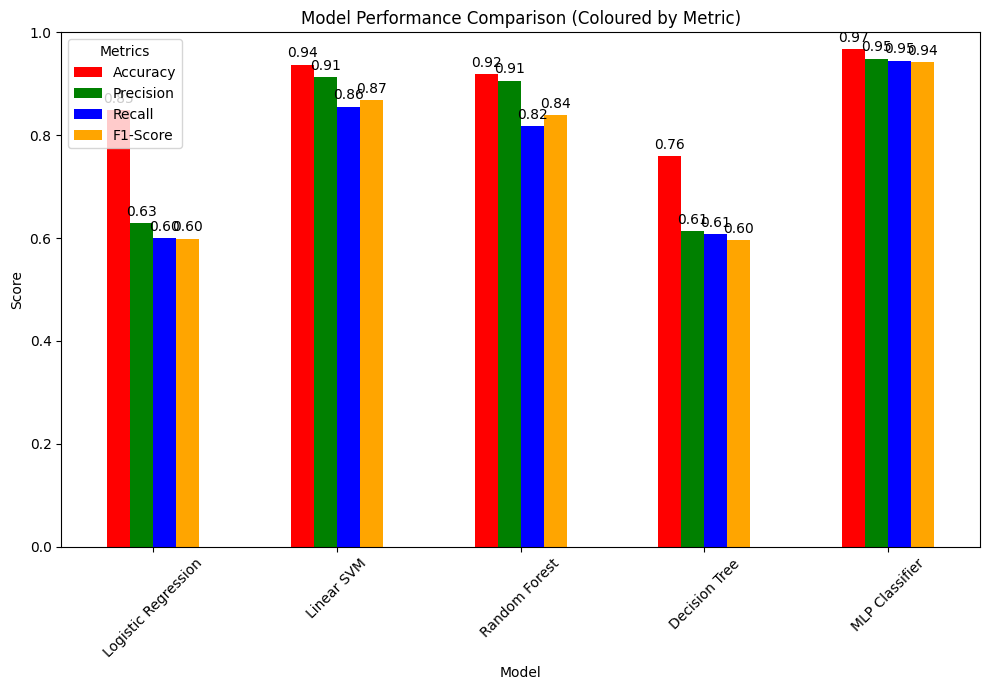

In [ ]:
# Set model as index
df_plot = df_results.set_index('Model')

# Define distinct colours for each metric
colors = ['red', 'green', 'blue', 'orange','black']

# Create bar chart
ax = df_plot.plot(kind='bar', figsize=(10, 7), color=colors)

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Model Performance Comparison (Coloured by Metric)")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.grid(False, axis='y')
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

<h2>External Test Set</h2>

In [ ]:
user_df = pd.read_csv('/content/drive/MyDrive/Colab_Objects/data/user_test_survey.csv')
user_df.head(3)

,Timestamp,Which domain of study are you currently pursuing or have you completed?,Describe in a few paragraphs why you are/were interested in this field? (at least 100 words please).,"Which specific sub-domain within your field of interest would you like to pursue or have you pursued? For example, Electrical Engineering or Safety Management.",Any reasons why? At least 50 words please,What is your education level?
0,2024/12/03 4:17:47 pm EET,Human Sciences,I have always enjoyed learning about culture a...,I would like to purse a course in Psychology,To understand human behaviour and mental healt...,"Postgraduate level (Masters, Doctorate)"
1,2024/12/03 4:38:30 pm EET,"Social Work, Employment Relations and Human Re...",I am committed to making a meaningful impact o...,Research,This is a new and exciting career opportunity ...,"Postgraduate level (Masters, Doctorate)"
2,2024/12/03 4:47:56 pm EET,Education,Education is the driving point towards a bette...,I have Bed Degree Intermediate & Senior phase ...,Content is Data the ways in which is why it is...,"University graduate (Diploma, Advanced diploma..."


In [ ]:
test_df = user_df.iloc[:,[2,1]]
test_df.rename(columns={test_df.columns[0]: 'features', test_df.columns[1]: 'target'}, inplace=True)
test_df = test_df[test_df['target'].isin(y.unique())]#get only qualified targets
test_df['features'] = test_df['features'].apply(preprocess)
test_df.head()

,features,target
0,always enjoyed learning culture communication ...,Human Sciences
2,education driving point towards better south a...,Education
4,always interested psychopathology particularly...,Human Sciences
5,maintain environmental sustainability djdjdjdn...,Agriculture and Environmental Sciences
6,interested field information technology gives ...,"Science, Engineering and Technology"


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# External test dataset
external_data = test_df
# Initialize results
external_final_results = []
external_all_conf_matrices = []

# === 3. Evaluate each best model ===
for model_name, content in best_per_model.items():
    vec = content['vectoriser']
    model = content['model']
    # Transform external features
    X_ext = vec.transform(external_data['features'])
    y_true = external_data['target']
    y_pred = model.predict(X_ext)
    # === 4. Compute metrics ===
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n====== {model_name} ======")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    # Store results
    external_final_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    external_all_conf_matrices.append(cm)

# === 6. Build results DataFrame ===
df_external_metrics = pd.DataFrame(external_final_results)
print("\nSummary Metrics:\n")
print(df_external_metrics)


====== Logistic Regression ======
Confusion Matrix:
 [[5 0 0 0 0 0]
 [1 2 0 0 0 0]
 [0 0 1 2 0 0]
 [1 1 0 4 0 0]
 [0 0 0 2 0 0]
 [6 0 0 3 0 8]]
Classification Report:
                                         precision    recall  f1-score   support

Agriculture and Environmental Sciences       0.38      1.00      0.56         5
      Economic and Management Sciences       0.67      0.67      0.67         3
                             Education       1.00      0.33      0.50         3
                        Human Sciences       0.36      0.67      0.47         6
                                   Law       0.00      0.00      0.00         2
   Science, Engineering and Technology       1.00      0.47      0.64        17

                              accuracy                           0.56        36
                             macro avg       0.57      0.52      0.47        36
                          weighted avg       0.73      0.56      0.56        36


====== Linear SVM ======
Co

In [ ]:
import pandas as pd
import pickle
from datetime import datetime
import os


# STEP 2: Define path in Google Drive
drive_path = '/content/drive/MyDrive/Colab_Objects/output'
os.makedirs(drive_path, exist_ok=True)  # Create if not exists

# STEP 3: Create DataFrames
df_results = pd.DataFrame(final_results)
df_external_metrics = pd.DataFrame(external_final_results)

# STEP 4: Display outputs
print("\n======= Final Averaged Results Across All Folds =======")
print(df_results)

print("\n======= External Test Set Metrics =======")
print(df_external_metrics)

print("\nBest fold per classifier (F1-score):")
for name, entry in best_per_model.items():
    print(f"{name}: {entry}")

# STEP 5: Generate timestamp for filenames
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# STEP 6: Define full file paths with timestamp in Drive
results_filename = os.path.join(drive_path, f"sbert_df_results_{timestamp}.pkl")
best_model_filename = os.path.join(drive_path, f"sbert_best_per_model_{timestamp}.pkl")
external_metrics_filename = os.path.join(drive_path, f"sbert_external_metrics_{timestamp}.pkl")

# STEP 7: Save the DataFrames and model results as pickle files
with open(results_filename, 'wb') as f:
    pickle.dump(df_results, f)

with open(best_model_filename, 'wb') as f:
    pickle.dump(best_per_model, f)

with open(external_metrics_filename, 'wb') as f:
    pickle.dump(df_external_metrics, f)

# STEP 8: Confirmation output
print("\nFiles saved to Google Drive under 'Colab_Objects/output':")
print(f"- {results_filename}")
print(f"- {best_model_filename}")
print(f"- {external_metrics_filename}")



======= Final Averaged Results Across All Folds =======
   Accuracy  Precision    Recall  F1-Score                Model
0  0.849421   0.629952  0.600014  0.598989  Logistic Regression
1  0.937194   0.912258  0.855770  0.868262           Linear SVM
2  0.919273   0.906171  0.817499  0.838763        Random Forest
3  0.759685   0.613207  0.608059  0.596369        Decision Tree
4  0.967728   0.948922  0.945086  0.942515       MLP Classifier

======= External Test Set Metrics =======
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.555556   0.569153  0.522876  0.472135
1           Linear SVM  0.694444   0.677778  0.728758  0.665709
2        Random Forest  0.416667   0.314134  0.340850  0.294931
3        Decision Tree  0.361111   0.220408  0.219608  0.203271
4       MLP Classifier  0.722222   0.753535  0.692810  0.638038

Best fold per classifier (F1-score):
Logistic Regression: {'f1': 0.643059163059163, 'model': LogisticRegression(max_iter=1000), 've